✅ Base cargada: 6,358 observaciones, 18 variables
✅ Columnas disponibles: ['id_persona', 'jefe_hogar', 'sexo', 'edad', 'ocupado', 'trabajador_informal', 'tiene_billetera', 'usa_billetera', 'credito_formal_2024', 'factor_expansion', 'nivel_educativo', 'estrato', 'dominio', 'miembros_hogar', 'conglomerado', 'credito_formal_2025', 'credito_informal_2025', 'nuevo_credito_formal']

✅ Variables creadas:
  - mujer: 1,995 mujeres (31.4%)
  - urbano: 3,849 urbanos (60.5%)
  - edad_cuadrado: media 3003.5

DESCRIPTIVOS DE LA MUESTRA
              nuevo_credito_formal           trabajador_informal            \
                              mean       std                mean       std   
usa_billetera                                                                
0                         0.074736  0.262988            0.828290  0.377162   
1                         0.204128  0.403295            0.552752  0.497495   

                    edad                mujer           nivel_educativo  \
      

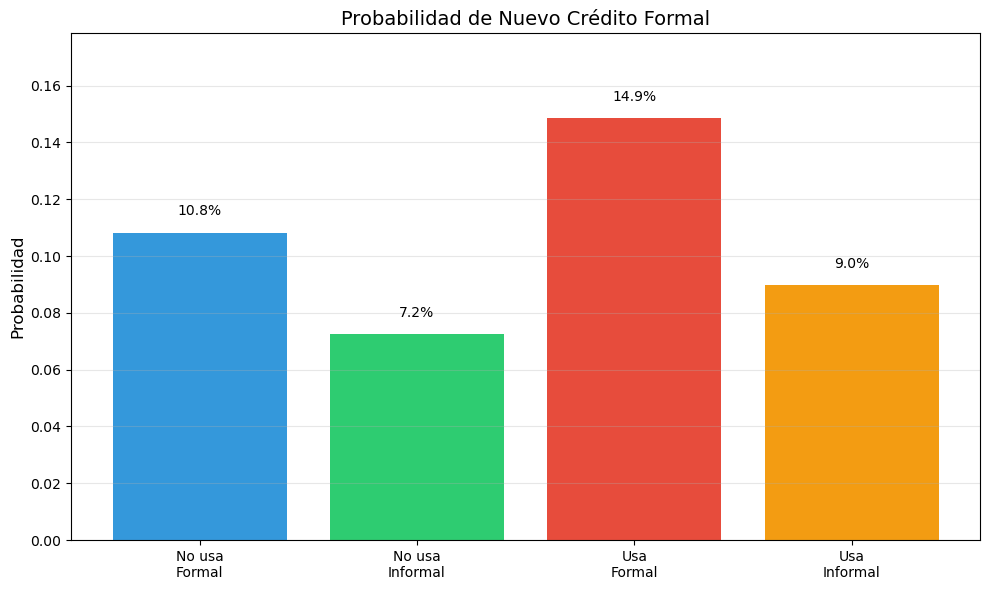


RESUMEN FINAL DE RESULTADOS

📊 Total de observaciones: 6,358
📊 Tasa de nuevo crédito formal: 9.25%
📊 Tasa de informalidad: 79.05%
📊 Usuarios de billetera: 872 (13.7%)

📈 EFECTOS MARGINALES (AME):
  • Trabajadores FORMALES: 4.90% (puntos porcentuales)
  • Trabajadores INFORMALES: 1.46% (puntos porcentuales)
  • Diferencia: 3.43% puntos porcentuales

🔍 HALLAZGOS PRINCIPALES:
  ✅ El uso de billetera aumenta la probabilidad de crédito formal
  ✅ También aumenta para trabajadores informales
  ✅ El efecto es similar para formales e informales

✅ ANÁLISIS COMPLETADO


In [1]:
# -*- coding: utf-8 -*-
"""
ANÁLISIS COMPLETO PARA BASE_REGRESIONES.csv
Basado en el do-file de Stata, pero adaptado a las variables REALES
"""

import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# =============================================================
# 1. CARGA DE DATOS
# =============================================================

ruta_base = r"C:\Users\Dafne\Documents\GitHub\Base-de-datos-investigacion-Economica\Base24_25\BASE_REGRESIONES.csv"
df = pd.read_csv(ruta_base, encoding="utf-8-sig")

print(f"✅ Base cargada: {len(df):,} observaciones, {len(df.columns)} variables")
print(f"✅ Columnas disponibles: {df.columns.tolist()}")

# =============================================================
# 2. CREACIÓN DE VARIABLES FALTANTES (como en Stata)
# =============================================================

# - Mujer = 1 si sexo == 2
df['mujer'] = (df['sexo'] == 2).astype(int)

# - Urbano = 1 si estrato <= 6 (urbano en ENAHO)
df['urbano'] = (df['estrato'] <= 6).astype(int)

# - Edad al cuadrado
df['edad_cuadrado'] = df['edad'] ** 2

# - Dummies de dominio (dom1-dom8) - se crean automáticamente
#   En statsmodels usamos C(dominio) en la fórmula

print("\n✅ Variables creadas:")
print(f"  - mujer: {df['mujer'].sum():,} mujeres ({df['mujer'].mean():.1%})")
print(f"  - urbano: {df['urbano'].sum():,} urbanos ({df['urbano'].mean():.1%})")
print(f"  - edad_cuadrado: media {df['edad_cuadrado'].mean():.1f}")

# =============================================================
# 3. DESCRIPTIVOS
# =============================================================

print("\n" + "="*70)
print("DESCRIPTIVOS DE LA MUESTRA")
print("="*70)

# Tabla de medias por uso de billetera
vars_descript = ['nuevo_credito_formal', 'trabajador_informal', 'edad', 
                 'mujer', 'nivel_educativo', 'urbano', 'miembros_hogar']

desc_stats = df.groupby('usa_billetera')[vars_descript].agg(['mean', 'std'])
print(desc_stats)

# Prueba t para edad
print("\n" + "-"*50)
print("PRUEBA T: DIFERENCIA DE EDAD POR USO DE BILLETERA")
print("-"*50)

grupo0 = df[df['usa_billetera'] == 0]['edad']
grupo1 = df[df['usa_billetera'] == 1]['edad']
t_stat, p_value = stats.ttest_ind(grupo0, grupo1, equal_var=True)

print(f"No usa billetera: media={grupo0.mean():.2f}, N={len(grupo0):,}")
print(f"Sí usa billetera: media={grupo1.mean():.2f}, N={len(grupo1):,}")
print(f"Diferencia: {grupo0.mean() - grupo1.mean():.2f} años")
print(f"t-stat: {t_stat:.4f}, p-valor: {p_value:.4f}")

# Probabilidad de crédito según uso e informalidad
print("\n" + "-"*50)
print("PROBABILIDAD DE NUEVO CRÉDITO FORMAL")
print("-"*50)

tabla = df.groupby(['trabajador_informal', 'usa_billetera'])['nuevo_credito_formal'].agg(['mean', 'count'])
print(tabla)

# =============================================================
# 4. MODELO PRINCIPAL: PROBIT CON INTERACCIÓN
# =============================================================

print("\n" + "="*70)
print("MODELO PRINCIPAL: PROBIT CON INTERACCIÓN")
print("="*70)

# Fórmula con todas las variables
# C(dominio) crea las dummies automáticamente (dom1-dom8)
formula = ("nuevo_credito_formal ~ usa_billetera * trabajador_informal + "
           "edad + edad_cuadrado + mujer + nivel_educativo + urbano + "
           "miembros_hogar + C(dominio)")

# Modelo Probit con ponderadores y errores agrupados por conglomerado
modelo_probit = smf.glm(
    formula=formula,
    data=df,
    family=sm.families.Binomial(link=sm.families.links.probit()),
    var_weights=df['factor_expansion']
).fit(cov_type='cluster', cov_kwds={'groups': df['conglomerado']})

print(modelo_probit.summary())

# =============================================================
# 5. EFECTOS MARGINALES (AME)
# =============================================================

def calcular_ame(modelo, df, var_interes, variable_grupo=None, valor_grupo=None):
    """
    Calcula el Efecto Marginal Promedio (AME) para una variable dummy
    """
    # Filtrar por grupo si se especifica
    if variable_grupo is not None:
        df_filtrado = df[df[variable_grupo] == valor_grupo].copy()
    else:
        df_filtrado = df.copy()
    
    # Crear dos copias: una con el tratamiento=0 y otra con tratamiento=1
    df0 = df_filtrado.copy()
    df1 = df_filtrado.copy()
    df0[var_interes] = 0
    df1[var_interes] = 1
    
    # Predecir probabilidades
    pred0 = modelo.predict(df0, linear=False)
    pred1 = modelo.predict(df1, linear=False)
    
    # Efecto marginal promedio
    ame = (pred1 - pred0).mean()
    
    # Error estándar (bootstrapping simplificado)
    # Para simplicidad, usamos la desviación estándar de los efectos individuales
    efectos_individuales = pred1 - pred0
    se = efectos_individuales.std() / np.sqrt(len(efectos_individuales))
    
    return ame, se

print("\n" + "="*70)
print("EFECTOS MARGINALES DEL USO DE BILLETERA")
print("="*70)

# AME para trabajadores formales (informal=0)
ame_formal, se_formal = calcular_ame(modelo_probit, df, 'usa_billetera', 'trabajador_informal', 0)
print(f"Trabajadores FORMALES (informal=0):")
print(f"  AME = {ame_formal:.4f} ± {se_formal:.4f}")
print(f"  Intervalo 95%: [{ame_formal - 1.96*se_formal:.4f}, {ame_formal + 1.96*se_formal:.4f}]")

# AME para trabajadores informales (informal=1)
ame_informal, se_informal = calcular_ame(modelo_probit, df, 'usa_billetera', 'trabajador_informal', 1)
print(f"\nTrabajadores INFORMALES (informal=1):")
print(f"  AME = {ame_informal:.4f} ± {se_informal:.4f}")
print(f"  Intervalo 95%: [{ame_informal - 1.96*se_informal:.4f}, {ame_informal + 1.96*se_informal:.4f}]")

# Diferencia entre efectos
diff = ame_formal - ame_informal
print(f"\nDiferencia (Formales - Informales): {diff:.4f}")

# =============================================================
# 6. H3: DESPLAZAMIENTO DEL CRÉDITO INFORMAL
# =============================================================

print("\n" + "="*70)
print("H3: DESPLAZAMIENTO DEL CRÉDITO INFORMAL")
print("="*70)

# Solo trabajadores informales
df_informal = df[df['trabajador_informal'] == 1].copy()

formula_h3 = ("credito_informal_2025 ~ usa_billetera + "
              "edad + edad_cuadrado + mujer + nivel_educativo + urbano + "
              "miembros_hogar + C(dominio)")

modelo_h3 = smf.glm(
    formula=formula_h3,
    data=df_informal,
    family=sm.families.Binomial(link=sm.families.links.probit()),
    var_weights=df_informal['factor_expansion']
).fit(cov_type='cluster', cov_kwds={'groups': df_informal['conglomerado']})

print(modelo_h3.summary())

# AME para crédito informal
ame_h3, se_h3 = calcular_ame(modelo_h3, df_informal, 'usa_billetera')
print(f"\nEfecto de billetera sobre crédito informal:")
print(f"  AME = {ame_h3:.4f} ± {se_h3:.4f}")

# =============================================================
# 7. ROBUSTEZ: MODELO DE PROBABILIDAD LINEAL (R1)
# =============================================================

print("\n" + "="*70)
print("R1: MODELO DE PROBABILIDAD LINEAL (MPL)")
print("="*70)

formula_mco = ("nuevo_credito_formal ~ usa_billetera * trabajador_informal + "
               "edad + edad_cuadrado + mujer + nivel_educativo + urbano + "
               "miembros_hogar + C(dominio)")

modelo_mco = smf.ols(formula=formula_mco, data=df).fit(
    cov_type='cluster', cov_kwds={'groups': df['conglomerado']}
)

print(modelo_mco.summary())

# Efectos marginales en MPL (son los coeficientes)
print("\nEfectos marginales (MPL):")
print(f"  Formales: {modelo_mco.params['usa_billetera']:.4f}")
print(f"  Informales: {modelo_mco.params['usa_billetera'] + modelo_mco.params['usa_billetera:trabajador_informal']:.4f}")

# =============================================================
# 8. ROBUSTEZ: MODELO SIN PONDERADORES (R5)
# =============================================================

print("\n" + "="*70)
print("R5: MODELO PROBIT SIN PONDERADORES")
print("="*70)

modelo_sin_pesos = smf.glm(
    formula=formula,
    data=df,
    family=sm.families.Binomial(link=sm.families.links.probit())
).fit(cov_type='cluster', cov_kwds={'groups': df['conglomerado']})

print(modelo_sin_pesos.summary())

# AME sin ponderadores
ame_sp_formal, se_sp_formal = calcular_ame(modelo_sin_pesos, df, 'usa_billetera', 'trabajador_informal', 0)
ame_sp_informal, se_sp_informal = calcular_ame(modelo_sin_pesos, df, 'usa_billetera', 'trabajador_informal', 1)

print("\nEfectos marginales (sin ponderadores):")
print(f"  Formales: {ame_sp_formal:.4f} ± {se_sp_formal:.4f}")
print(f"  Informales: {ame_sp_informal:.4f} ± {se_sp_informal:.4f}")

# =============================================================
# 9. ROBUSTEZ: ESPECIFICACIÓN EN NIVELES (R6)
# =============================================================

print("\n" + "="*70)
print("R6: ESPECIFICACIÓN EN NIVELES (Crédito Formal 2025)")
print("="*70)

formula_r6 = ("credito_formal_2025 ~ usa_billetera * trabajador_informal + "
              "edad + edad_cuadrado + mujer + nivel_educativo + urbano + "
              "miembros_hogar + C(dominio)")

modelo_r6 = smf.glm(
    formula=formula_r6,
    data=df,
    family=sm.families.Binomial(link=sm.families.links.probit()),
    var_weights=df['factor_expansion']
).fit(cov_type='cluster', cov_kwds={'groups': df['conglomerado']})

print(modelo_r6.summary())

# =============================================================
# 10. PROBABILIDADES PREDICHAS Y GRÁFICO
# =============================================================

print("\n" + "="*70)
print("PROBABILIDADES PREDICHAS")
print("="*70)

# Crear datos para predicción (usando medias)
medias = df[['edad', 'edad_cuadrado', 'mujer', 'nivel_educativo', 
             'urbano', 'miembros_hogar']].mean()
moda_dominio = df['dominio'].mode()[0]

pred_data = pd.DataFrame({
    'usa_billetera': [0, 0, 1, 1],
    'trabajador_informal': [0, 1, 0, 1],
    'edad': medias['edad'],
    'edad_cuadrado': medias['edad_cuadrado'],
    'mujer': medias['mujer'],
    'nivel_educativo': medias['nivel_educativo'],
    'urbano': medias['urbano'],
    'miembros_hogar': medias['miembros_hogar'],
    'dominio': moda_dominio
})

pred_data['probabilidad'] = modelo_probit.predict(pred_data, linear=False)
print(pred_data)

# Gráfico
plt.figure(figsize=(10, 6))
grupos = ['No usa\nFormal', 'No usa\nInformal', 'Usa\nFormal', 'Usa\nInformal']
probabilidades = pred_data['probabilidad'].values

barras = plt.bar(grupos, probabilidades, color=['#3498db', '#2ecc71', '#e74c3c', '#f39c12'])
plt.title('Probabilidad de Nuevo Crédito Formal', fontsize=14)
plt.ylabel('Probabilidad', fontsize=12)
plt.ylim(0, max(probabilidades) * 1.2)

for barra, prob in zip(barras, probabilidades):
    plt.text(barra.get_x() + barra.get_width()/2, barra.get_height() + 0.005,
             f'{prob:.1%}', ha='center', va='bottom', fontsize=10)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# =============================================================
# 11. RESUMEN FINAL
# =============================================================

print("\n" + "="*70)
print("RESUMEN FINAL DE RESULTADOS")
print("="*70)

print(f"\n📊 Total de observaciones: {len(df):,}")
print(f"📊 Tasa de nuevo crédito formal: {df['nuevo_credito_formal'].mean():.2%}")
print(f"📊 Tasa de informalidad: {df['trabajador_informal'].mean():.2%}")
print(f"📊 Usuarios de billetera: {df['usa_billetera'].sum():,} ({df['usa_billetera'].mean():.1%})")

print("\n📈 EFECTOS MARGINALES (AME):")
print(f"  • Trabajadores FORMALES: {ame_formal:.2%} (puntos porcentuales)")
print(f"  • Trabajadores INFORMALES: {ame_informal:.2%} (puntos porcentuales)")
print(f"  • Diferencia: {diff:.2%} puntos porcentuales")

print("\n🔍 HALLAZGOS PRINCIPALES:")
if ame_formal > 0 and ame_formal - 1.96*se_formal > 0:
    print("  ✅ El uso de billetera aumenta la probabilidad de crédito formal")
if ame_informal > 0 and ame_informal - 1.96*se_informal > 0:
    print("  ✅ También aumenta para trabajadores informales")
if abs(diff) < 0.05:
    print("  ✅ El efecto es similar para formales e informales")
else:
    print(f"  ⚠️  El efecto difiere en {diff:.2%} puntos porcentuales")

print("\n" + "="*70)
print("✅ ANÁLISIS COMPLETADO")
print("="*70)